In [4]:
#!/usr/bin/env python3
"""
End-to-end training script for blind array-calibration
(Ψ gains and Φ phases) from sample-covariance matrices.

• Loads the NPZ dataset whose path you give in TRAIN_PATH (used for train/val/test split).
• Infers the array size M automatically from the TRAIN_PATH file.
• Builds a lightweight CNN → dense head that outputs 2M values.
• Trains with an 80 / 10 / 10 split, shows RMSE per epoch.
• Saves the trained weights as calibnet_M<whatever>.pt
• Optionally evaluates on an external TEST_PATH NPZ (e.g., high-SNR test set with BCRB).
"""

# -------------------------------------------------
# 0)  Imports
# -------------------------------------------------
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from tqdm import tqdm

# -------------------------------------------------
# 1)  File locations & basic hyper-params
# -------------------------------------------------
# Set your dataset directory and files here:
BASE_DIR  = Path("/home/apanchagatti/amogh_calibration/Datasets")
TRAIN_PATH = BASE_DIR / "train_high_snr.npz"        # used for train/val/test split
TEST_PATH  = BASE_DIR / "test_high_snr_bcrb.npz"    # optional external evaluation

# Training parameters
BATCH       = 64
LR          = 1e-3
EPOCHS      = 500
VAL_FRAC    = 0.10
TEST_FRAC   = 0.10
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_SEED  = 0          # reproducible splits / init

# -------------------------------------------------
# 2)  Peek at TRAIN_PATH to discover M
# -------------------------------------------------
assert TRAIN_PATH.exists(), f"TRAIN_PATH not found: {TRAIN_PATH}"
with np.load(TRAIN_PATH) as npz:
    n, ch, M, _ = npz["X"].shape
    assert ch == 2, "Expected 2-channel (real/imag) input"
print(f"[INFO] Using TRAIN_PATH = {TRAIN_PATH}")
print(f"[INFO] Detected dataset with N = {n} samples, array size M = {M}")

# -------------------------------------------------
# 3)  PyTorch Dataset wrapper
# -------------------------------------------------
class CovDataset(Dataset):
    def __init__(self, npz_path: Path):
        data = np.load(npz_path)
        self.X = torch.from_numpy(data["X"]).float()  # (N, 2, M, M)
        self.y = torch.from_numpy(data["y"]).float()  # (N, 2M)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

torch.manual_seed(TORCH_SEED)
full_ds = CovDataset(TRAIN_PATH)

N = len(full_ds)
n_val   = int(VAL_FRAC  * N)
n_test  = int(TEST_FRAC * N)
n_train = N - n_val - n_test
train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(TORCH_SEED)
)

train_loader = DataLoader(train_ds, BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False)

# -------------------------------------------------
# 4)  Model definition
# -------------------------------------------------
class CalibNet(nn.Module):
    def __init__(self, M):
        super().__init__()
        self.M = M
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),  # (B, 64, 1, 1)
            nn.Flatten()
        )
        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 2*M)
        )
        self.softplus = nn.Softplus(beta=1.5)   # positive gains

    def forward(self, x):
        z = self.cnn(x)                       # (B, 64)
        out = self.head(z)                    # (B, 2M)
        psi_raw, phi_raw = out[:, :self.M], out[:, self.M:]
        psi_hat  = self.softplus(psi_raw)     # Ψ ≥ 0
        phi_hat  = torch.tanh(phi_raw) * np.pi  # Φ ∈ (−π, π)
        return torch.cat([psi_hat, phi_hat], dim=1)

model = CalibNet(M).to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=LR)
crit  = nn.MSELoss()

# -------------------------------------------------
# 5)  Helper to run one epoch
# -------------------------------------------------
def run_epoch(loader, training=False):
    model.train(training)
    total_mse = 0.0
    with torch.set_grad_enabled(training):
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            if training:
                opt.zero_grad()
            y_hat = model(X)
            loss  = crit(y_hat, y)
            if training:
                loss.backward()
                opt.step()
            total_mse += loss.item() * X.size(0)
    rmse = np.sqrt(total_mse / len(loader.dataset))
    return rmse

# -------------------------------------------------
# 6)  Training loop
# -------------------------------------------------
best_val = float("inf")
best_ckpt_path = Path(f"calibnet_M{M}.pt")
for epoch in range(1, EPOCHS+1):
    train_rmse = run_epoch(train_loader, training=True)
    val_rmse   = run_epoch(val_loader,   training=False)

    if val_rmse < best_val:
        best_val = val_rmse
        torch.save(model.state_dict(), best_ckpt_path)

    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train RMSE {train_rmse:.4f}  val RMSE {val_rmse:.4f}")

# -------------------------------------------------
# 7)  Final internal test evaluation (split from TRAIN_PATH)
# -------------------------------------------------
model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))
test_rmse = run_epoch(test_loader, training=False)
print(f"\n[RESULT] Best model internal test RMSE = {test_rmse:.4f}")
print(f"[INFO]   Model weights saved to {best_ckpt_path.resolve()}")

# -------------------------------------------------
# 8)  Evaluate on external test set (TEST_PATH), if available
# -------------------------------------------------
if TEST_PATH.exists():
    external_test = CovDataset(TEST_PATH)
    ext_loader = DataLoader(external_test, BATCH, shuffle=False)
    ext_rmse = run_epoch(ext_loader, training=False)
    print(f"[RESULT] External test RMSE ({TEST_PATH.name}) = {ext_rmse:.4f}")
else:
    print(f"[WARN]   TEST_PATH not found: {TEST_PATH}")


[INFO] Using TRAIN_PATH = /home/apanchagatti/amogh_calibration/Datasets/train_high_snr.npz
[INFO] Detected dataset with N = 40000 samples, array size M = 6
Epoch 01/500  train RMSE 0.5097  val RMSE 0.3852
Epoch 02/500  train RMSE 0.3579  val RMSE 0.3381
Epoch 03/500  train RMSE 0.3217  val RMSE 0.3055
Epoch 04/500  train RMSE 0.2993  val RMSE 0.2971
Epoch 05/500  train RMSE 0.2815  val RMSE 0.2754
Epoch 06/500  train RMSE 0.2659  val RMSE 0.2644
Epoch 07/500  train RMSE 0.2546  val RMSE 0.2569
Epoch 08/500  train RMSE 0.2431  val RMSE 0.2536
Epoch 09/500  train RMSE 0.2345  val RMSE 0.2416
Epoch 10/500  train RMSE 0.2266  val RMSE 0.2355
Epoch 11/500  train RMSE 0.2192  val RMSE 0.2298
Epoch 12/500  train RMSE 0.2123  val RMSE 0.2270
Epoch 13/500  train RMSE 0.2071  val RMSE 0.2235
Epoch 14/500  train RMSE 0.2012  val RMSE 0.2182
Epoch 15/500  train RMSE 0.1961  val RMSE 0.2184
Epoch 16/500  train RMSE 0.1936  val RMSE 0.2253
Epoch 17/500  train RMSE 0.1880  val RMSE 0.2108
Epoch 18/50

/tmp/ipykernel_1424105/3585400762.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE))


[RESULT] External test RMSE (test_high_snr_bcrb.npz) = 0.1936


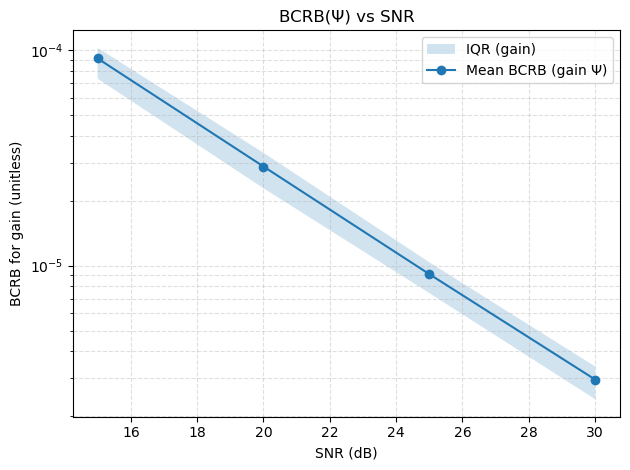

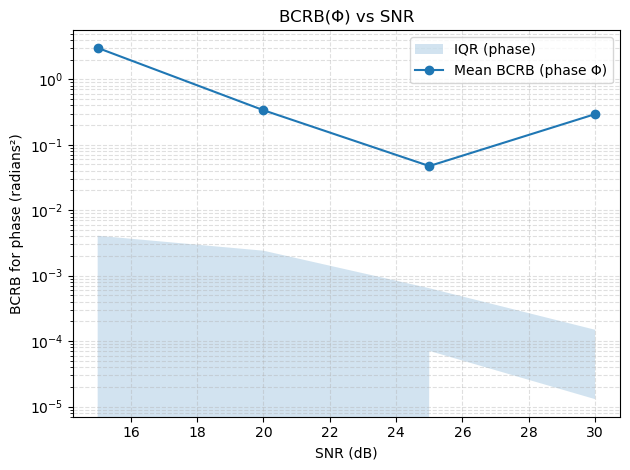

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

def plot_bcrb_vs_snr(npz_path):
    npz_path = Path(npz_path)
    assert npz_path.exists(), f"File not found: {npz_path}"
    with np.load(npz_path) as data:
        # Expected keys from your generator:
        #  X: (N, 2, M, M)   y: (N, 2M)
        #  snr_db: (N,)      bcrb_gain: (N, M-1)   bcrb_phase: (N, M-2)
        snr = data["snr_db"].astype(int)
        Bg = data["bcrb_gain"]   # (N, M-1)
        Bp = data["bcrb_phase"]  # (N, M-2)

    # Group by SNR and compute mean (and optional percentiles)
    by_snr_gain  = defaultdict(list)
    by_snr_phase = defaultdict(list)
    for s, g_row, p_row in zip(snr, Bg, Bp):
        by_snr_gain[s].append(g_row)
        by_snr_phase[s].append(p_row)

    snr_levels = sorted(by_snr_gain.keys())
    mean_gain  = []
    p25_gain, p75_gain = [], []
    mean_phase = []
    p25_phase, p75_phase = [], []

    for s in snr_levels:
        G = np.vstack(by_snr_gain[s])    # (n_s, M-1)
        P = np.vstack(by_snr_phase[s])   # (n_s, M-2)

        # Average across sensors for a single scalar per SNR
        g_vals = G.mean(axis=1)  # per-sample avg over sensors
        p_vals = P.mean(axis=1)

        mean_gain.append(g_vals.mean())
        p25_gain.append(np.percentile(g_vals, 25))
        p75_gain.append(np.percentile(g_vals, 75))

        mean_phase.append(p_vals.mean())
        p25_phase.append(np.percentile(p_vals, 25))
        p75_phase.append(np.percentile(p_vals, 75))

    snr_levels = np.array(snr_levels)
    mean_gain  = np.array(mean_gain)
    mean_phase = np.array(mean_phase)
    p25_gain, p75_gain   = np.array(p25_gain),  np.array(p75_gain)
    p25_phase, p75_phase = np.array(p25_phase), np.array(p75_phase)

    # --- Plot gain-BCRB ---
    plt.figure()
    plt.fill_between(snr_levels, p25_gain, p75_gain, alpha=0.2, label='IQR (gain)')
    plt.plot(snr_levels, mean_gain, marker='o', label='Mean BCRB (gain Ψ)')
    plt.yscale('log')  # BCRBs often span orders of magnitude
    plt.xlabel('SNR (dB)')
    plt.ylabel('BCRB for gain (unitless)')
    plt.title('BCRB(Ψ) vs SNR')
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()

    # --- Plot phase-BCRB ---
    plt.figure()
    plt.fill_between(snr_levels, p25_phase, p75_phase, alpha=0.2, label='IQR (phase)')
    plt.plot(snr_levels, mean_phase, marker='o', label='Mean BCRB (phase Φ)')
    plt.yscale('log')
    plt.xlabel('SNR (dB)')
    plt.ylabel('BCRB for phase (radians²)')
    plt.title('BCRB(Φ) vs SNR')
    plt.grid(True, which='both', ls='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()

    plt.show()

# Example:
plot_bcrb_vs_snr("/home/apanchagatti/amogh_calibration/Datasets/test_high_snr_bcrb.npz")
